# Baseline v0.3d - Stress de ejecucion y latencia

Este notebook es una pieza de control de realidad. En los notebooks anteriores vimos que el modelo encontraba senales muy buenas en el instante `t`. Aqui preguntamos algo mas parecido a operar: **que pasa si la entrada ocurre 2, 4 u 8 segundos despues?**

No entrenamos un modelo nuevo. Solo leemos los resultados generados por `scripts/experiments/baseline_v03d_execution_stress.py` y los explicamos con tablas/graficos.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

PROJECT = Path.cwd()
if not (PROJECT / 'docs').exists() and (PROJECT.parent / 'docs').exists():
    PROJECT = PROJECT.parent

OUT_DIR = PROJECT / 'data' / 'experiments' / 'baseline_v03d_execution_stress'

summary = pd.read_csv(OUT_DIR / 'execution_stress_summary.csv')
by_split = pd.read_csv(OUT_DIR / 'execution_stress_by_split.csv')
by_day = pd.read_csv(OUT_DIR / 'execution_stress_by_day.csv')
latency_support = pd.read_csv(OUT_DIR / 'latency_support.csv')
recommended = pd.read_csv(OUT_DIR / 'recommended_execution_scenarios.csv')
meta = json.loads((OUT_DIR / 'summary.json').read_text(encoding='utf-8'))

print('Senales combinadas:', meta['signals'])
print('Proyecto:', PROJECT.resolve())
print('Carpeta:', OUT_DIR.resolve())

Senales combinadas: 646
Proyecto: C:\Users\ftpx\Desktop\Recolector\edgerunner
Carpeta: C:\Users\ftpx\Desktop\Recolector\edgerunner\data\experiments\baseline_v03d_execution_stress


## Que estamos midiendo

La politica base es la que quedo viva en v0.3c:

- feature set: `v03_conservative_no_micro`;
- score accionable: `score_buy = P(up) - P(down)`;
- regla de senal: `score_buy >= 0,65`;
- unidad de accion: market-frame, no token duplicado.

La novedad es que ahora no evaluamos solo el movimiento desde `t`, sino que buscamos la fila de entrada en `t + latencia` y calculamos el markout desde ahi. Si esto se cae, la senal puede existir, pero no estar lista para ejecucion real.

In [2]:
latency_support[['latency_seconds', 'signals', 'entry_supported', 'entry_supported_pct']].round(2)

,latency_seconds,signals,entry_supported,entry_supported_pct
0,0,646,646,100.00
1,2,646,640,99.07
2,4,646,631,97.68
3,8,646,617,95.51


La cobertura de filas retrasadas es alta. Por tanto, si la senal empeora con latencia, no es porque falten datos: es porque la oportunidad llega tarde o se consume rapido.

In [3]:
cols = [
    'scenario_id', 'latency_seconds', 'execution', 'cooldown_seconds', 'limit_policy',
    'actions', 'retention_pct', 'hit_up_pct', 'wrong_down_pct', 'net_mean',
    'net_sum', 'max_drawdown_ticks', 'positive_splits', 'splits_with_actions'
]

recommended[cols].head(10).round(2)

,scenario_id,latency_seconds,execution,cooldown_seconds,limit_policy,actions,retention_pct,hit_up_pct,wrong_down_pct,net_mean,net_sum,max_drawdown_ticks,positive_splits,splits_with_actions
0,lat0s__low_spread_plus_0p5tick__cd0s__day50_se...,0,low_spread_plus_0p5tick,0,day50_session3,381,58.98,91.86,3.94,9.37,3568.39,-14.24,5,5
1,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,0,low_spread_plus_0p5tick,16,day50_session3,376,58.20,91.76,3.99,9.34,3512.62,-14.24,5,5
2,lat0s__low_spread_plus_0p5tick__cd0s__none,0,low_spread_plus_0p5tick,0,none,541,83.75,90.02,4.99,8.92,4823.42,-24.77,5,5
3,lat0s__low_spread_plus_0p5tick__cd120s__day50_...,0,low_spread_plus_0p5tick,120,day50_session3,369,57.12,91.06,4.61,9.05,3338.97,-14.24,5,5
4,lat0s__low_spread_plus_0p5tick__cd16s__none,0,low_spread_plus_0p5tick,16,none,524,81.11,89.89,5.15,8.91,4670.11,-24.77,5,5
5,lat0s__cross_plus_0p5tick__cd0s__day50_session3,0,cross_plus_0p5tick,0,day50_session3,406,62.85,91.63,4.93,9.01,3659.81,-18.08,5,5
6,lat0s__cross_plus_0p5tick__cd120s__day50_session3,0,cross_plus_0p5tick,120,day50_session3,391,60.53,91.82,4.60,9.01,3522.29,-14.24,5,5
7,lat0s__low_spread_plus_0p5tick__cd60s__day50_s...,0,low_spread_plus_0p5tick,60,day50_session3,369,57.12,91.06,4.34,8.99,3318.89,-14.24,5,5
8,lat0s__cross_plus_0p5tick__cd0s__none,0,cross_plus_0p5tick,0,none,646,100.00,89.16,5.73,8.74,5646.26,-24.77,5,5
9,lat0s__cross_plus_0p5tick__cd16s__none,0,cross_plus_0p5tick,16,none,615,95.20,89.11,6.02,8.78,5401.23,-24.77,5,5


## Escenario principal para leer la decision

Uso un escenario facil de defender:

- entrar solo si el spread de entrada es `<= 1 tick`;
- anadir buffer de `0,5 tick`;
- cooldown de `16s` por mercado;
- limite de `50` acciones por dia y `3` por sesion.

No es el escenario con mas acciones, pero es conservador y entendible.

In [4]:
main_mask = (
    summary['execution'].eq('low_spread_plus_0p5tick')
    & summary['cooldown_seconds'].eq(16)
    & summary['limit_policy'].eq('day50_session3')
)

main = summary.loc[main_mask, cols].sort_values('latency_seconds')
main.round(2)

,scenario_id,latency_seconds,execution,cooldown_seconds,limit_policy,actions,retention_pct,hit_up_pct,wrong_down_pct,net_mean,net_sum,max_drawdown_ticks,positive_splits,splits_with_actions
1,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,0,low_spread_plus_0p5tick,16,day50_session3,376,58.20,91.76,3.99,9.34,3512.62,-14.24,5,5
53,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,2,low_spread_plus_0p5tick,16,day50_session3,343,53.10,59.48,26.24,2.96,1014.47,-116.23,4,5
106,lat4s__low_spread_plus_0p5tick__cd16s__day50_s...,4,low_spread_plus_0p5tick,16,day50_session3,371,57.43,50.13,35.58,0.20,74.75,-90.80,3,5
134,lat8s__low_spread_plus_0p5tick__cd16s__day50_s...,8,low_spread_plus_0p5tick,16,day50_session3,369,57.12,42.82,36.86,-0.76,-280.11,-289.25,0,5


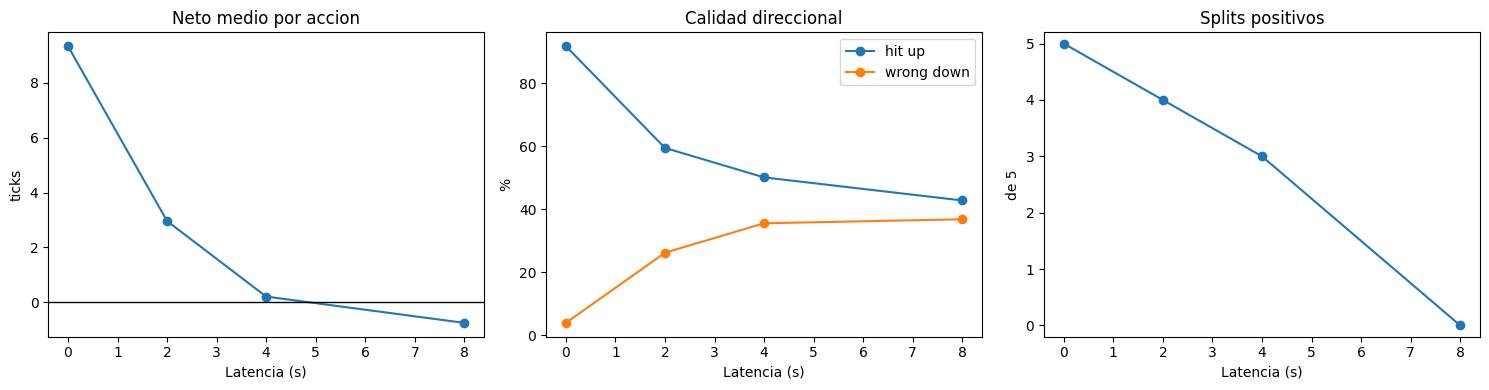

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(main['latency_seconds'], main['net_mean'], marker='o')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Neto medio por accion')
axes[0].set_xlabel('Latencia (s)')
axes[0].set_ylabel('ticks')

axes[1].plot(main['latency_seconds'], main['hit_up_pct'], marker='o', label='hit up')
axes[1].plot(main['latency_seconds'], main['wrong_down_pct'], marker='o', label='wrong down')
axes[1].set_title('Calidad direccional')
axes[1].set_xlabel('Latencia (s)')
axes[1].set_ylabel('%')
axes[1].legend()

axes[2].plot(main['latency_seconds'], main['positive_splits'], marker='o')
axes[2].set_title('Splits positivos')
axes[2].set_xlabel('Latencia (s)')
axes[2].set_ylabel('de 5')
axes[2].set_ylim(-0.2, 5.2)

plt.tight_layout()

La imagen cuenta la historia: en latencia `0s` la politica es muy buena; con `2s` sigue positiva en agregado pero se degrada mucho; con `4s` casi no hay margen; con `8s` ya es negativa. Para bot, el numero peligroso no es el promedio bonito, sino la caida rapida al retrasar la entrada.

In [6]:
main_scenario_ids = main['scenario_id'].tolist()
split_table = by_split[by_split['scenario_id'].isin(main_scenario_ids)].copy()

split_cols = [
    'scenario_id', 'split', 'actions', 'hit_up_pct', 'wrong_down_pct',
    'net_mean', 'net_sum', 'net_positive_pct', 'max_drawdown_ticks'
]

split_table[split_cols].sort_values(['scenario_id', 'split']).round(2)

,scenario_id,split,actions,hit_up_pct,wrong_down_pct,net_mean,net_sum,net_positive_pct,max_drawdown_ticks
80,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,F1,80,91.25,3.75,9.01,721.14,86.25,-3.54
81,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,F2,100,88.00,6.00,8.80,879.91,87.00,-6.11
82,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,F3,52,90.38,5.77,10.18,529.25,84.62,-14.24
83,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,F4,80,97.50,2.50,11.85,947.88,93.75,-7.24
84,lat0s__low_spread_plus_0p5tick__cd16s__day50_s...,TEST,64,92.19,1.56,6.79,434.44,85.94,-6.15
320,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,F1,71,64.79,21.13,3.04,215.56,54.93,-19.44
321,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,F2,100,72.00,18.00,4.06,406.18,65.00,-30.80
322,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,F3,49,53.06,28.57,2.71,132.56,48.98,-22.37
323,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,F4,60,58.33,25.00,5.89,353.65,56.67,-22.75
324,lat2s__low_spread_plus_0p5tick__cd16s__day50_s...,TEST,63,39.68,44.44,-1.48,-93.48,26.98,-96.04


## El test terminal es la alarma

El test terminal no se uso para elegir la frontera. Si la politica falla ahi con latencia, no podemos decir que esta lista para ejecutar aunque el promedio de folds siga positivo.

In [7]:
test_rows = split_table[split_table['split'].eq('TEST')].copy()
test_rows['latency_seconds'] = test_rows['scenario_id'].str.extract(r'lat(\d+)s').astype(int)

test_rows[
    ['latency_seconds', 'actions', 'hit_up_pct', 'wrong_down_pct', 'net_mean', 'net_sum', 'net_positive_pct', 'max_drawdown_ticks']
].sort_values('latency_seconds').round(2)

,latency_seconds,actions,hit_up_pct,wrong_down_pct,net_mean,net_sum,net_positive_pct,max_drawdown_ticks
84,0,64,92.19,1.56,6.79,434.44,85.94,-6.15
324,2,63,39.68,44.44,-1.48,-93.48,26.98,-96.04
564,4,66,45.45,43.94,-0.74,-48.83,31.82,-60.10
804,8,66,43.94,31.82,-0.30,-19.53,27.27,-31.98


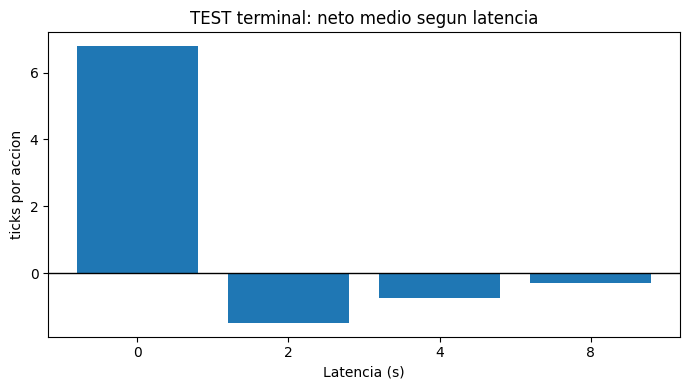

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(test_rows.sort_values('latency_seconds')['latency_seconds'].astype(str), test_rows.sort_values('latency_seconds')['net_mean'])
ax.axhline(0, color='black', linewidth=1)
ax.set_title('TEST terminal: neto medio segun latencia')
ax.set_xlabel('Latencia (s)')
ax.set_ylabel('ticks por accion')
plt.tight_layout()

En test, `0s` es excelente, pero `2s` ya pasa a negativo. Esto no invalida toda la investigacion: invalida la idea de saltar directamente a bot con el target actual. El modelo parece detectar movimientos muy cercanos; ahora necesitamos comprobar si puede detectarlos **antes** de que ocurran o si necesitamos ejecucion mas rapida.

## Comparacion rapida con entrada sin filtro de spread

Tambien miro una variante menos estricta (`cross_plus_0p5tick`) para ver si el problema era solo el filtro de spread. El patron se repite, asi que la conclusion de latencia es robusta.

In [9]:
cross = summary[
    summary['execution'].eq('cross_plus_0p5tick')
    & summary['cooldown_seconds'].eq(16)
    & summary['limit_policy'].eq('day50_session3')
].sort_values('latency_seconds')

cross[cols].round(2)

,scenario_id,latency_seconds,execution,cooldown_seconds,limit_policy,actions,retention_pct,hit_up_pct,wrong_down_pct,net_mean,net_sum,max_drawdown_ticks,positive_splits,splits_with_actions
6,lat0s__cross_plus_0p5tick__cd16s__day50_session3,0,cross_plus_0p5tick,16,day50_session3,399,61.76,91.23,5.01,8.95,3571.58,-18.08,5,5
54,lat2s__cross_plus_0p5tick__cd16s__day50_session3,2,cross_plus_0p5tick,16,day50_session3,397,61.46,63.22,25.44,2.91,1156.87,-106.06,4,5
102,lat4s__cross_plus_0p5tick__cd16s__day50_session3,4,cross_plus_0p5tick,16,day50_session3,394,60.99,53.55,33.76,0.39,153.63,-96.77,2,5
139,lat8s__cross_plus_0p5tick__cd16s__day50_session3,8,cross_plus_0p5tick,16,day50_session3,392,60.68,45.41,36.48,-0.79,-309.33,-318.48,0,5


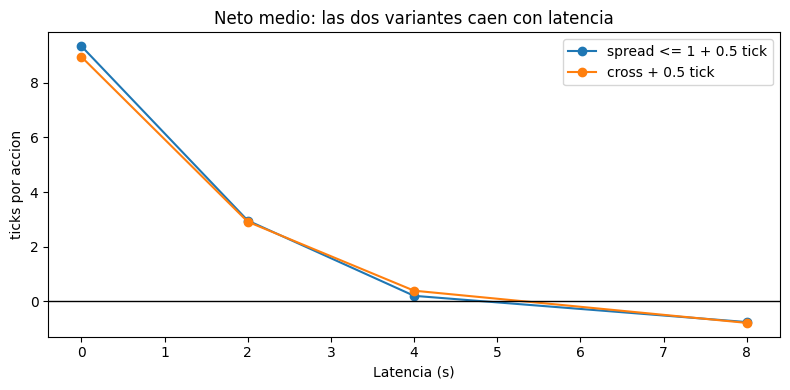

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(main['latency_seconds'], main['net_mean'], marker='o', label='spread <= 1 + 0.5 tick')
ax.plot(cross['latency_seconds'], cross['net_mean'], marker='o', label='cross + 0.5 tick')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Neto medio: las dos variantes caen con latencia')
ax.set_xlabel('Latencia (s)')
ax.set_ylabel('ticks por accion')
ax.legend()
plt.tight_layout()

## Decision

**Decision v0.3d:**

- `GO` para investigar un target/modelo consciente de latencia;
- `NO GO` para bot;
- `NO GO` para modelos complejos todavia.

En palabras simples: el baseline encuentra edge, pero demasiado pegado al movimiento. El siguiente paso no es meter una red neuronal; es cambiar la pregunta de entrenamiento para que el modelo aprenda a seleccionar operaciones que sigan vivas despues de una latencia realista.

In [11]:
# Pequenas comprobaciones para no dejar el notebook contando una historia rota.
assert meta['signals'] == 646
assert set(latency_support['latency_seconds']) == {0, 2, 4, 8}
assert main['latency_seconds'].tolist() == [0, 2, 4, 8]
assert test_rows['latency_seconds'].sort_values().tolist() == [0, 2, 4, 8]

print('Checks OK')

Checks OK
